Paquetes necesarios


In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Número de filas con al menos el 90% de píxeles blancos del máximo: 9
Posiciones de las filas con al menos el 90% de píxeles blancos del máximo: [  6  12  15  20  21  82  88  98 100]


(0.0, 512.0)

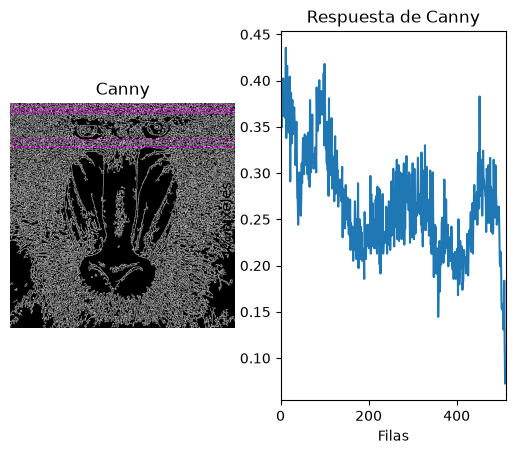

In [23]:
img_og = cv2.imread('mandril.jpg')

gris = cv2.cvtColor(img_og, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 50, 150)
img = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
fil_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de columnas, segundo valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por fila
fils = fil_counts / (255 * canny.shape[1])
maxfil = fils.max()

resultado_filas = np.where(fils >= maxfil * 0.9)
print("Número de filas con al menos el 90% de píxeles blancos del máximo:", len(resultado_filas[0]))
print("Posiciones de las filas con al menos el 90% de píxeles blancos del máximo:", resultado_filas[0])
for fila in resultado_filas[0]:
    cv2.line(img, (0, fila), (canny.shape[1], fila), (255, 0, 255), 1)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(img, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(fils)
#Rango en x definido por las filas
plt.xlim([0, canny.shape[1]])

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

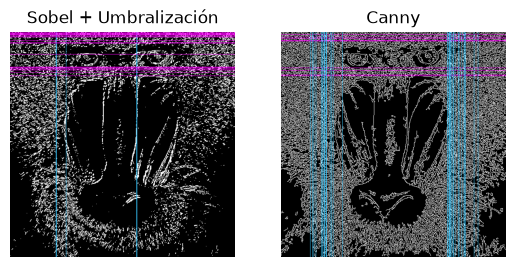

In [22]:
img = cv2.imread('mandril.jpg')

gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)
sobel8np = np.uint8(np.abs(sobel))
#Define valor umbral
valorUmbral = 110

#Obtiene imagen umbralizada para dicho valor definido
_, imagenUmbralizada = cv2.threshold(sobel8np, valorUmbral, 255, cv2.THRESH_BINARY)

col_counts = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

cols = col_counts[0] / (255 * imagenUmbralizada.shape[0])
maxcol = cols.max()
resultado_columnas = np.where(cols >= maxcol * 0.9)

img1 = cv2.cvtColor(imagenUmbralizada, cv2.COLOR_GRAY2RGB)
for col in resultado_columnas[0]:
    cv2.line(img1, (col, 0), (col, imagenUmbralizada.shape[0]), (55, 200, 255), 1)

fil_counts = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
fils = fil_counts / (255 * imagenUmbralizada.shape[1])
maxfil = fils.max()

resultado_filas = np.where(fils >= maxfil * 0.9)
for fila in resultado_filas[0]:
    cv2.line(img1, (0, fila), (imagenUmbralizada.shape[1], fila), (255, 0, 255), 1)

#--------------------------------------------------------------------------------------------

canny = cv2.Canny(gris, 50, 150)
img2 = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

fil_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

fils = fil_counts / (255 * canny.shape[1])
maxfil = fils.max()
resultado_filas = np.where(fils >= maxfil * 0.9)
for fila in resultado_filas[0]:
    cv2.line(img2, (0, fila), (canny.shape[1], fila), (255, 0, 255), 1)

col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols = col_counts[0] / (255 * canny.shape[0])
maxcol = cols.max()
resultado_columnas = np.where(cols >= maxcol * 0.9)
for col in resultado_columnas[0]:
    cv2.line(img2, (col, 0), (col, canny.shape[0]), (55, 200, 255), 1)


plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel + Umbralización")
plt.imshow(img1, cmap='gray');

plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Canny")
plt.imshow(img2, cmap='gray');

Los resulatdos obtenidos difieren considerablemente, sobre todo en el número de columnas verticales. Con Canny se puede observar la imagen con más bordes en la zona del pelaje, por lo que el número de píxeles blancos aumenta, aumentando así el número de columnas con el 90% del máximo. Sin embargo, con Sobel + Umbralización se pueden ver varias filas horizontales más, en la zona inferior de los ojos.

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [20]:
vid = cv2.VideoCapture(0, cv2.CAP_DSHOW)
disponible = 0 
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)

while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        if disponible > 0:
            img = cv2.flip(frame, 1)

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            pgray = cv2.cvtColor(pframe, cv2.COLOR_BGR2GRAY)
            dif = cv2.absdiff(gray, pgray)
            dif = cv2.GaussianBlur(dif, (3, 3), 0)
            framem=cv2.flip(dif, 1)
            objetos = eliminadorFondo.apply(framem)  

            sx = cv2.Sobel(objetos, cv2.CV_64F, 1, 0)
            sy = cv2.Sobel(objetos, cv2.CV_64F, 0, 1)
            sobel = cv2.add(sx, sy)
            sobel8 = cv2.convertScaleAbs(sobel)

            _, imagenUmbralizada = cv2.threshold(sobel8, 100, 255, cv2.THRESH_BINARY)

            col_counts = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
            cols = col_counts[0] / (255 * imagenUmbralizada.shape[0])
            maxcol = cols.max()

            indices = np.where(cols >= 0.05 * maxcol)[0]

            if len(indices) > 0:
                first = indices[0]
                last = indices[-1]
                x = (first + last) // 2

            cv2.line(img, (first, 0), (first, dif.shape[0]), (255, 0, 255), 3)
            cv2.line(img, (last, 0), (last, dif.shape[0]), (255, 0, 255), 3)
            cv2.line(img, (x, 0), (x, dif.shape[0]), (0, 255, 0), 3)
            cv2.rectangle(img, (0, 0), (first, dif.shape[0]), (0, 255, 255), -1)
            cv2.rectangle(img, (last, 0), (dif.shape[1], dif.shape[0]), (0, 255, 255), -1)


            cv2.imshow('Diferencia', img)

        else:
            disponible = 1

        #Copia fotograma actual para la diferencia en el siguiente forograma
        pframe = frame.copy()
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()